In [15]:
import glob
import json
import os
import pandas as pd
import numpy as np
from pathlib import Path
import jinja2
from IPython.display import display, HTML


In [16]:
def set_project_root(marker="main.py"):
    """
    Finds the project root by searching upwards for a specific marker
    and sets the current working directory.
    """
    current_dir = Path.cwd()

    # Iterate through the current directory and all its parents
    for path in [current_dir, *current_dir.parents]:
        if (path / marker).exists():
            os.chdir(path)
            print(f"Working directory set to: {path}")
            return path

    print(f"Marker '{marker}' not found. Working directory remains: {current_dir}")
    return current_dir

# Execute the function
set_project_root()

Working directory set to: /home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output


PosixPath('/home/ruben-eschauzier/data-processing/process-raw-caching-jbr-output')

In [17]:
def find_failing_queries_per_template(file_path):
    """
    Counts the number of failed queries per template in a JSON file.

    Args:
        file_path (str): The path to the JSON file.

    Returns:
        dict: A dictionary mapping template names to their failure counts.
    """
    failure_counts = {}

    with open(file_path, 'r') as file:
        data = json.load(file)

    for entry in data:
        if "error" in entry:
            # Safely navigate the nested dictionary
            template = entry.get("sequenceElement", {}).get("template")

            if template:
                # Initialize to 0 if template is new, then add 1
                failure_counts[template] = failure_counts.get(template, 0) + 1

    return dict(sorted(failure_counts.items()))


def compare_failures_across_files(directory_path):
    """
    Reads all .json files in a directory, extracts failure counts,
    and returns a pandas DataFrame for comparison.
    """
    all_results = {}

    # Locate all JSON files in the target directory
    file_pattern = os.path.join(directory_path, '*.json')
    json_files = glob.glob(file_pattern)

    for file_path in json_files:
        file_name = os.path.basename(file_path)
        # Extract failure counts for the current file
        counts = find_failing_queries_per_template(file_path)
        all_results[file_name] = counts

    # Convert the nested dictionary to a DataFrame
    # This automatically aligns the templates (rows) and files (columns)
    df = pd.DataFrame(all_results)

    # Replace NaN values with 0 and convert to integers
    df = df.fillna(0).astype(int)

    # Sort the index (templates) alphabetically
    df = df.sort_index()

    return df

def find_failing_queries(file_path, target_template):
    """
    Extracts failing queries for a specific template from a JSON file.

    Args:
        file_path (str): The path to the JSON file.
        target_template (str): The template name to filter by (e.g., 'interactive-discover-8').

    Returns:
        list: A list of dictionaries representing the failing queries.
    """
    # Load the JSON data
    with open(file_path, 'r') as file:
        data = json.load(file)

    failing_queries = []

    # Iterate through entries and filter
    for entry in data:
        if "error" in entry:
            sequence_element = entry.get("sequenceElement", {})
            template = sequence_element.get("template")

            if template == target_template:
                # Remove the clutter
                entry.pop("sequenceInstantiationCounts")
                failing_queries.append(entry)

    return failing_queries


In [18]:
failing_queries_all_runs = compare_failures_across_files("data")
failing_queries_all_runs

,query-results-raw-query-cache-s.json,query-results-raw-default-dockerfile.json,query-results-raw-cache-l.json,query-results-raw-query-cache-l.json,query-results-raw-query-cache-estimate-l.json,query-results-raw-default.json,query-results-raw-cache-s.json,query-results-raw-query-cache-estimate-s.json,query-results-raw-query-cache-m.json,query-results-raw-query-cache-estimate-m.json,query-results-raw-cache-m.json
interactive-discover-1,0,0,4,1,0,3,0,0,0,0,0
interactive-discover-2,5,0,0,6,6,4,2,3,3,3,4
interactive-discover-3,3,0,4,2,3,4,2,4,4,4,0
interactive-discover-4,21,10,22,21,22,21,22,20,20,22,21
interactive-discover-5,90,45,95,91,91,90,90,90,91,92,91
interactive-discover-6,70,35,73,71,71,70,73,73,70,74,69
interactive-discover-7,101,50,100,100,99,99,100,99,100,99,100
interactive-discover-8,27,5,12,32,22,10,12,24,26,19,14
interactive-short-1,2,0,1,0,3,0,2,4,3,0,1
interactive-short-2,100,50,100,100,100,100,100,100,100,100,100


In [19]:
# Compare to failures with default
# failing_discover_8_default= find_failing_queries("data/query-results-raw-default.json",
#                                                                "interactive-discover-8")
# failing_discover_8_default


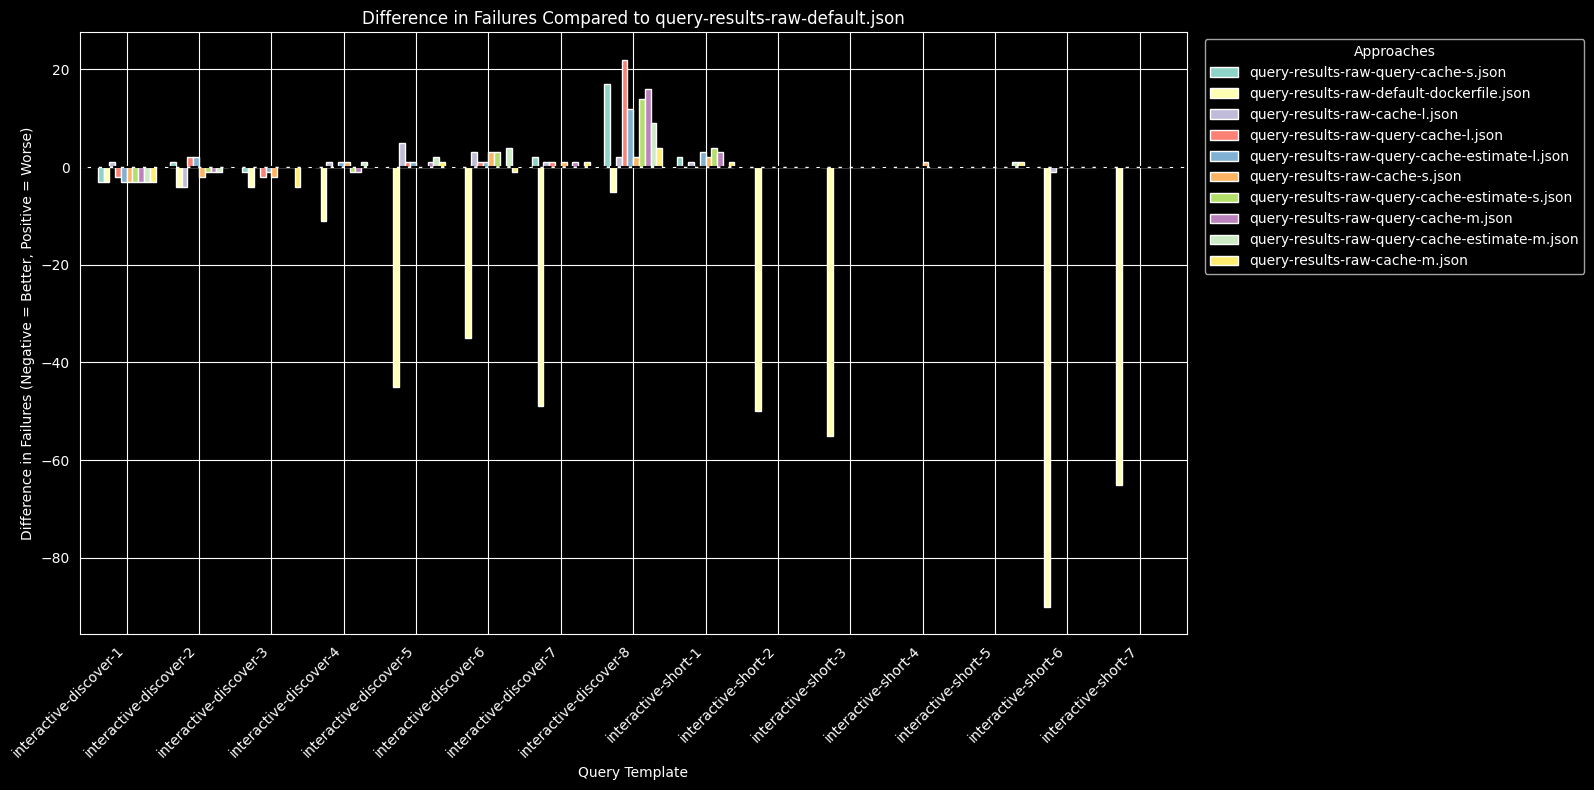

In [20]:
from matplotlib import pyplot as plt

def plot_baseline_differences(df, baseline_column):
    """
    Plots the difference in failure counts between various approaches and a baseline
    using a vertical grouped bar chart.
    """
    if baseline_column not in df.columns:
        raise ValueError(f"Baseline '{baseline_column}' not found.")

    # Calculate the difference from the baseline
    df_diff = df.drop(columns=[baseline_column]).subtract(df[baseline_column], axis=0)

    # Create a vertical grouped bar chart with a wider figure size
    fig, ax = plt.subplots(figsize=(16, 8))
    df_diff.plot(kind='bar', ax=ax, width=0.8)

    # Add a horizontal line at 0 to mark the baseline
    ax.axhline(0, color='black', linewidth=1.5, linestyle='--')

    # Formatting
    ax.set_title(f'Difference in Failures Compared to {baseline_column}')
    ax.set_ylabel('Difference in Failures (Negative = Better, Positive = Worse)')
    ax.set_xlabel('Query Template')

    # Rotate x-axis labels to ensure readability
    plt.xticks(rotation=45, ha='right')

    # Place legend outside the plot area
    ax.legend(title='Approaches', bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()

plot_baseline_differences(failing_queries_all_runs, "query-results-raw-default.json")

In [21]:
# Get the per template execution time and hit rate
import os
import json
from typing import Literal
import pandas as pd
import numpy as np
from IPython.display import HTML, display

def generate_comparison_dfs_pooled(files, filterMode: Literal["refinement", "non-refinement"]):
    """
    Parses result files, pools variance across specific query instantiations
    identified by template, name, and id, and generates a DataFrame for each cache type.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        records = []
        for entry in data:
            refinement_metadata = entry.get("sequenceElement").get("refinementMetadata").get("patternIds")
            if refinement_metadata and filterMode == "refinement":
                continue
            if not refinement_metadata and filterMode == 'non-refinement':
                continue

            template = entry.get("sequenceElement", {}).get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState") or \
                        entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    total = hits + cache_stats.get("misses", 0)
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            # Ensure all composite keys exist before appending
            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000,
                    'hit_rate': hit_rate
                })

        if not records:
            continue

        df_records = pd.DataFrame(records)
        # Calculate variance and mean per exact instantiation (template + name + id)
        inst_stats = df_records.groupby(['template', 'name', 'id']).agg(
            n=('time_s', 'count'),
            var_time=('time_s', 'var'),
            mean_time=('time_s', 'mean'),
            mean_hr=('hit_rate', 'mean')
        ).reset_index()

        inst_stats['var_time'] = inst_stats['var_time'].fillna(0)

        # 3. Pool the metrics up to the template level
        def pool_metrics(group):
            total_weight = (group['n'] - 1).sum()
            if total_weight > 0:
                pooled_var = ((group['n'] - 1) * group['var_time']).sum() / total_weight
            else:
                pooled_var = 0.0

            return pd.Series({
                'Avg Time (s)': group['mean_time'].mean(),
                'Std Time (s)': np.sqrt(pooled_var),
                'Avg Hit Rate': group['mean_hr'].mean()
            })

        template_metrics = inst_stats.groupby('template').apply(pool_metrics, include_groups=False).to_dict('index')
        all_results[label] = template_metrics

    # 4. Group by cache type
    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results.get(algo, {}).get(tmpl, {}).get(metric, np.nan)
                             for tmpl in all_results.get(algo, {})}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Std Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def generate_comparison_dfs(files):
    """
    Parses result files and generates a separate DataFrame for each cache type,
    comparing its sizes against the default baselines.
    """
    all_results = {}

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        template_data = {}
        for entry in data:
            template = entry.get("sequenceElement", {}).get("template")
            exec_time = entry.get("time")

            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState")
            if not cache_str:
                cache_str = entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")

            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    misses = cache_stats.get("misses", 0)
                    total = hits + misses
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    pass

            if template and exec_time is not None:
                if template not in template_data:
                    template_data[template] = {'times': [], 'hit_rates': []}
                template_data[template]['times'].append(exec_time)
                if not np.isnan(hit_rate):
                    template_data[template]['hit_rates'].append(hit_rate)

        avg_metrics = {}
        for tmpl, metrics in template_data.items():
            avg_time = (sum(metrics['times']) / len(metrics['times'])) / 1000
            avg_hr = sum(metrics['hit_rates']) / len(metrics['hit_rates']) if metrics['hit_rates'] else np.nan
            avg_metrics[tmpl] = {'Avg Time (s)': avg_time, 'Avg Hit Rate': avg_hr}

        all_results[label] = avg_metrics

    baselines = ['default', 'default-n-b']
    cache_groups = {}

    for label in all_results.keys():
        if label in baselines:
            continue

        # Extract cache type assuming format: {cache_type}-{size}
        if label.endswith(('-s', '-m', '-l')):
            cache_type = label[:-2]
            if cache_type not in cache_groups:
                cache_groups[cache_type] = []
            cache_groups[cache_type].append(label)

    # Create a DataFrame for each cache type
    dfs_dict = {}
    size_order = {'s': 0, 'm': 1, 'l': 2}

    for cache_type, labels in cache_groups.items():
        # Sort labels by size: -s, -m, -l
        sorted_labels = sorted(labels, key=lambda x: size_order.get(x[-1], 3))
        columns_to_include = [b for b in baselines if b in all_results] + sorted_labels

        reformatted = {
            (algo, metric): {tmpl: all_results[algo][tmpl].get(metric, np.nan) for tmpl in all_results[algo]}
            for algo in columns_to_include
            for metric in ['Avg Time (s)', 'Avg Hit Rate']
        }
        dfs_dict[cache_type] = pd.DataFrame(reformatted).sort_index()

    return dfs_dict

def display_comparison_dfs(dfs_dict):
    """
    Iterates through the dictionary and displays each DataFrame
    as an HTML table with a clear heading.
    """
    for cache_type, df in dfs_dict.items():
        # Print a clear heading for the cache type
        display(HTML(f"<h3>Cache Type: {cache_type.upper()}</h3>"))

        # Display the actual DataFrame
        display(df)

files = glob.glob("data/*.json")
df_avg_times = generate_comparison_dfs_pooled(files, "refinement")
display_comparison_dfs(df_avg_times)

default                                cache-s  \
                       Avg Time (s) Std Time (s) Avg Hit Rate Avg Time (s)   
interactive-discover-1     5.213408    22.748963          NaN     2.056308   
interactive-discover-2     8.237142    29.605182          NaN     6.355100   
interactive-discover-3    11.203236    34.051664          NaN     7.135482   
interactive-discover-4     6.762689    22.174566          NaN     7.512311   
interactive-discover-5     1.278067     0.326962          NaN     1.993244   
interactive-discover-6    91.958170    22.240500          NaN   100.216960   
interactive-discover-7   108.140908    14.896226          NaN   108.216392   
interactive-discover-8    11.219845     3.787402          NaN    13.568527   
interactive-short-1        1.591840     0.913488          NaN     5.027470   
interactive-short-2      185.623220     1.533744          NaN   185.722810   
interactive-short-3      149.148400     6.399999          NaN   147.844644   
interactive-short-4        0.394036     1.930612          NaN     1.320936   
interactive-short-5        0.494680     0.446312          NaN     0.591140   
interactive-short-6      185.141450     0.391153          NaN   185.653271   
interactive-short-7      172.902543     1.882057          NaN   175.229564   

                                                      cache-m               \
                       Std Time (s) Avg Hit Rate Avg Time (s) Std Time (s)   
interactive-discover-1     1.744720     0.430423     2.449623     3.988723   
interactive-discover-2    22.712553     0.228616     6.811525    24.388217   
interactive-discover-3    23.741543     0.153421     3.907764     2.065697   
interactive-discover-4    27.961875     0.231188     2.773078     4.801485   
interactive-discover-5     5.113087     0.453899     5.018667    20.003094   
interactive-discover-6    30.884853     0.145418    92.872810    16.329929   
interactive-discover-7    10.573320     0.239372   106.570008    15.887814   
interactive-discover-8     9.238136     0.141282    10.258036     8.572496   
interactive-short-1       24.345011     0.326283     4.831600    21.839789   
interactive-short-2        2.450260     0.048365   174.144840    24.326649   
interactive-short-3        7.524658     0.302727   147.913922     6.927489   
interactive-short-4        8.351417     0.861738     0.636307     3.286877   
interactive-short-5        0.695684     0.437236     2.413990    18.468829   
interactive-short-6        2.754959     0.066864   184.734414     6.230038   
interactive-short-7        7.101898     0.222211   173.958171    17.441777   

                                         cache-l                            
                       Avg Hit Rate Avg Time (s) Std Time (s) Avg Hit Rate  
interactive-discover-1     0.567590     6.020931    24.351703     0.641433  
interactive-discover-2     0.335766     3.497817     5.053328     0.411433  
interactive-discover-3     0.263454     9.892255    29.637852     0.275679  
interactive-discover-4     0.299954     5.044444    19.810591     0.336216  
interactive-discover-5     0.622602    11.744722    36.066870     0.744730  
interactive-discover-6     0.224503    95.475880     8.410913     0.359405  
interactive-discover-7     0.302546   107.319783    17.425347     0.346525  
interactive-discover-8     0.226951    10.208573     9.875597     0.382167  
interactive-short-1        0.422712     4.860080    21.393798     0.467244  
interactive-short-2        0.130651   182.156850    18.471098     0.295321  
interactive-short-3        0.310504   150.805011    17.298854     0.393319  
interactive-short-4        0.930952     1.714029     5.012635     0.942857  
interactive-short-5        0.537305     1.433070     3.442982     0.532292  
interactive-short-6        0.108416   186.032607    12.469586     0.191478  
interactive-short-7        0.265461   182.551186    28.756196     0.332171

default                            \
                       Avg Time (s) Std Time (s) Avg Hit Rate   
interactive-discover-1     5.213408    22.748963          NaN   
interactive-discover-2     8.237142    29.605182          NaN   
interactive-discover-3    11.203236    34.051664          NaN   
interactive-discover-4     6.762689    22.174566          NaN   
interactive-discover-5     1.278067     0.326962          NaN   
interactive-discover-6    91.958170    22.240500          NaN   
interactive-discover-7   108.140908    14.896226          NaN   
interactive-discover-8    11.219845     3.787402          NaN   
interactive-short-1        1.591840     0.913488          NaN   
interactive-short-2      185.623220     1.533744          NaN   
interactive-short-3      149.148400     6.399999          NaN   
interactive-short-4        0.394036     1.930612          NaN   
interactive-short-5        0.494680     0.446312          NaN   
interactive-short-6      185.141450     0.391153          NaN   
interactive-short-7      172.902543     1.882057          NaN   

                       query-cache-estimate-s                            \
                                 Avg Time (s) Std Time (s) Avg Hit Rate   
interactive-discover-1               3.236885     3.987505     0.496095   
interactive-discover-2               9.690258    26.742747     0.270244   
interactive-discover-3              12.159018    31.626451     0.198698   
interactive-discover-4               2.910533     2.658254     0.220543   
interactive-discover-5               1.289389     0.203632     0.525196   
interactive-discover-6              94.312560     2.307173     0.146164   
interactive-discover-7             106.968967    22.409501     0.228523   
interactive-discover-8              20.977427    36.430613     0.183461   
interactive-short-1                  9.138200    34.308496     0.329451   
interactive-short-2                188.711930     5.687074     0.178044   
interactive-short-3                145.333256     3.679737     0.286583   
interactive-short-4                  0.117671     0.040013     0.893333   
interactive-short-5                  0.492360     0.106815     0.455430   
interactive-short-6                182.752157    20.801143     0.084039   
interactive-short-7                172.089500     1.907550     0.196080   

                       query-cache-estimate-m                            \
                                 Avg Time (s) Std Time (s) Avg Hit Rate   
interactive-discover-1               3.431400     3.831258     0.499273   
interactive-discover-2               8.586242    27.418516     0.322355   
interactive-discover-3              12.356182    30.202590     0.197553   
interactive-discover-4               8.845689    31.868332     0.204908   
interactive-discover-5               5.453300    24.719782     0.563523   
interactive-discover-6              94.691320     3.374851     0.148552   
interactive-discover-7             107.964383    16.446623     0.219754   
interactive-discover-8              18.308291    24.677059     0.194891   
interactive-short-1                  1.950820     2.894375     0.349916   
interactive-short-2                189.536700     6.043138     0.184118   
interactive-short-3                145.123733     3.041462     0.278486   
interactive-short-4                  0.289557     1.373190     0.880000   
interactive-short-5                  2.412400    18.339414     0.477818   
interactive-short-6                185.203464     0.965252     0.080458   
interactive-short-7                172.096950     1.518958     0.198495   

                       query-cache-estimate-l                            
                                 Avg Time (s) Std Time (s) Avg Hit Rate  
interactive-discover-1               4.461769    13.508257     0.499698  
interactive-discover-2              13.083433    35.942011     0.322520  
interactive-discover-3              12.272255    30.659753     0.168101  


default                           query-cache-s  \
                       Avg Time (s) Std Time (s) Avg Hit Rate  Avg Time (s)   
interactive-discover-1     5.213408    22.748963          NaN      3.244808   
interactive-discover-2     8.237142    29.605182          NaN     12.320767   
interactive-discover-3    11.203236    34.051664          NaN      8.618145   
interactive-discover-4     6.762689    22.174566          NaN      4.966022   
interactive-discover-5     1.278067     0.326962          NaN      1.366767   
interactive-discover-6    91.958170    22.240500          NaN     94.522960   
interactive-discover-7   108.140908    14.896226          NaN    110.651508   
interactive-discover-8    11.219845     3.787402          NaN     19.919982   
interactive-short-1        1.591840     0.913488          NaN      6.579920   
interactive-short-2      185.623220     1.533744          NaN    186.094370   
interactive-short-3      149.148400     6.399999          NaN    146.947944   
interactive-short-4        0.394036     1.930612          NaN      0.566800   
interactive-short-5        0.494680     0.446312          NaN      0.623360   
interactive-short-6      185.141450     0.391153          NaN    183.056357   
interactive-short-7      172.902543     1.882057          NaN    174.885464   

                                                 query-cache-m               \
                       Std Time (s) Avg Hit Rate  Avg Time (s) Std Time (s)   
interactive-discover-1     2.683516     0.416797      4.439615    10.867738   
interactive-discover-2    32.892568     0.319365      8.574683    27.938587   
interactive-discover-3    25.066046     0.139786     10.282609    32.945306   
interactive-discover-4    19.522388     0.222567      2.400456     1.449688   
interactive-discover-5     0.561419     0.444634      3.688122    18.661509   
interactive-discover-6     5.004178     0.143987     94.478030     3.636709   
interactive-discover-7    16.832666     0.217159    109.083683     1.940645   
interactive-discover-8    23.552556     0.144110     20.249782    24.019080   
interactive-short-1       29.799522     0.322075      6.849820    30.334415   
interactive-short-2        2.977027     0.054816    186.065060     2.698007   
interactive-short-3        5.723058     0.288128    147.319411     5.805765   
interactive-short-4        2.982573     0.839487      0.412114     3.057994   
interactive-short-5        1.812957     0.435401      0.794050     2.211898   
interactive-short-6       18.327658     0.090791    185.407036     1.882542   
interactive-short-7        6.411685     0.207166    174.394021     5.697930   

                                    query-cache-l                            
                       Avg Hit Rate  Avg Time (s) Std Time (s) Avg Hit Rate  
interactive-discover-1     0.417888      4.600254    16.558684     0.410774  
interactive-discover-2     0.289260     11.932633    34.129387     0.286796  
interactive-discover-3     0.166178      7.798891    23.869611     0.150370  
interactive-discover-4     0.224487      5.244333    19.947174     0.235678  
interactive-discover-5     0.417505      3.387089    18.683386     0.413010  
interactive-discover-6     0.145112     96.087420    18.339865     0.160456  
interactive-discover-7     0.231800    108.955658     0.925622     0.194485  
interactive-discover-8     0.162783     20.519991    28.000723     0.146264  
interactive-short-1        0.344379      1.375240     0.279153     0.303958  
interactive-short-2        0.056077    185.507210     1.622024     0.057688  
interactive-short-3        0.290660    147.887611     6.678739     0.302292  
interactive-short-4        0.865758      0.601229     4.035367     0.828964  
interactive-short-5        0.448618      0.435510     0.156379     0.455441  
interactive-short-6        0.094684    185.400393     2.309809     0.090657  
interactive-short-7        0.193093    174.764650     7.024580     0.196276

In [22]:
import os
import json
import pandas as pd
from typing import Literal

def extract_raw_metrics(files, filter_mode: Literal["refinement", "non-refinement", "all"] = "all", target_file: str = None):
    """
    Parses result files and aggregates raw execution times into lists.
    Optionally limits parsing to a single specified file.
    """
    records = []

    if target_file:
        files = [f for f in files if target_file in f]

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        for entry in data:
            seq_element = entry.get("sequenceElement") or {}
            ref_metadata = seq_element.get("refinementMetadata") or {}
            pattern_ids = ref_metadata.get("patternIds")

            if filter_mode == "refinement" and pattern_ids:
                continue
            if filter_mode == "non-refinement" and not pattern_ids:
                continue
            template = seq_element.get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")
            cache_str = entry.get("@comunica/persistent-cache-manager:sourceState")
            if not cache_str:
                cache_str = entry.get("@comunica/persistent-cache-manager:sourceStateQuerySource")
            is_error = True if entry.get("error") else False
            hit_rate = np.nan
            if cache_str:
                try:
                    cache_stats = json.loads(cache_str)
                    hits = cache_stats.get("hits", 0)
                    misses = cache_stats.get("misses", 0)
                    total = hits + misses
                    hit_rate = (hits / total) if total > 0 else 0.0
                except json.JSONDecodeError:
                    print("ERROR")
                    pass

            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'label': label,
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000,
                    'hit_rate': hit_rate,
                    'error': is_error
                })

    if not records:
        return pd.DataFrame()

    df_records = pd.DataFrame(records)
    df_records['hit_rate'] = df_records['hit_rate'].round(2)

    raw_times_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['time_s'].apply(list).reset_index()

    raw_hit_rates_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['hit_rate'].apply(list).reset_index()

    raw_error_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    )['error'].apply(list).reset_index()

    raw_times_df.rename(columns={'time_s': 'execution_times_s'}, inplace=True)
    raw_times_df['execution_count'] = raw_times_df['execution_times_s'].apply(len)

    return raw_times_df, raw_hit_rates_df, raw_error_df

In [30]:
files = glob.glob("data/*.json")

# Remove column width limits to display full lists
pd.set_option('display.max_colwidth', None)
df_raw, df_hit_rate, df_error = extract_raw_metrics(files, "refinement", target_file="query-results-raw-default-2.json")
df_raw_df, df_hit_rate_df, df_error_df = extract_raw_metrics(files, "refinement", target_file="query-results-raw-default-dockerfile.json")
df_raw_rh, df_hit_rate_rh, df_error_rh = extract_raw_metrics(files, "refinement", target_file="query-results-raw-default-rehydrate.json")


# Display the raw lists for a specific template or cache label
print("Default")
display(df_raw[df_raw["name"] == "sequence_0"])
print("Default DockerFile")
display(df_raw_df[df_raw_df["name"] == "sequence_0"])
print("Default rehydrate")
display(df_raw_rh[df_raw_rh["name"] == "sequence_0"])

# display(df_error[df_error["name"] == "sequence_0"])
# Display hit rates
# display(df_hit_rate[df_hit_rate["name"] == "sequence_0"])
pd.reset_option('display.max_colwidth')

Default


,label,template,name,id,execution_times_s,execution_count
0,default-2,interactive-discover-1,sequence_0,22,"[5.131, 0.553, 0.836, 0.567, 0.703, 0.893, 0.639, 0.666, 0.544, 0.745]",10
1,default-2,interactive-discover-1,sequence_0,34,"[4.428, 4.789, 5.149, 4.705, 5.565, 9.764, 5.01, 6.494, 8.102, 4.862]",10
2,default-2,interactive-discover-1,sequence_0,7,"[0.74, 0.81, 0.878, 0.835, 0.691, 0.629, 0.857, 0.98, 0.847, 0.971]",10
3,default-2,interactive-discover-2,sequence_0,16,"[67.178, 1.014, 1.007, 1.073, 1.151, 3.895, 1.153, 0.933, 0.863, 1.04]",10
4,default-2,interactive-discover-3,sequence_0,21,"[0.649, 0.563, 0.275, 0.333, 0.378, 0.28, 0.374, 0.32, 0.274, 0.272]",10
5,default-2,interactive-discover-3,sequence_0,3,"[6.917, 5.708, 158.162, 6.195, 126.397, 6.221, 5.518, 6.138, 5.857, 6.616]",10
6,default-2,interactive-discover-3,sequence_0,31,"[0.628, 0.601, 0.641, 0.632, 0.615, 1.213, 0.915, 0.597, 0.614, 0.807]",10
7,default-2,interactive-discover-4,sequence_0,33,"[0.99, 1.495, 1.442, 1.046, 1.533, 1.162, 1.442, 1.715, 1.327, 1.376]",10
8,default-2,interactive-discover-4,sequence_0,4,"[0.179, 0.195, 0.279, 0.205, 0.54, 0.191, 0.182, 0.227, 0.182, 0.2]",10
9,default-2,interactive-discover-5,sequence_0,20,"[0.31, 0.297, 6.302, 0.333, 0.325, 0.309, 0.359, 0.311, 0.32, 0.581]",10


Default DockerFile


,label,template,name,id,execution_times_s,execution_count
0,default-dockerfile,interactive-discover-1,sequence_0,22,"[0.808, 1.026, 0.771, 0.992, 0.921]",5
1,default-dockerfile,interactive-discover-1,sequence_0,34,"[4.935, 4.495, 4.941, 4.363, 5.253]",5
2,default-dockerfile,interactive-discover-1,sequence_0,7,"[1.332, 1.417, 1.236, 1.239, 1.138]",5
13,default-dockerfile,interactive-discover-2,sequence_0,16,"[2.247, 1.994, 2.477, 2.499, 2.499]",5
25,default-dockerfile,interactive-discover-3,sequence_0,21,"[0.307, 0.302, 0.709, 0.586, 0.588]",5
26,default-dockerfile,interactive-discover-3,sequence_0,3,"[6.801, 7.175, 6.872, 7.92, 7.361]",5
27,default-dockerfile,interactive-discover-3,sequence_0,31,"[0.64, 0.605, 0.631, 0.648, 0.599]",5
36,default-dockerfile,interactive-discover-4,sequence_0,33,"[2.522, 2.268, 2.411, 2.594, 2.708]",5
37,default-dockerfile,interactive-discover-4,sequence_0,4,"[0.212, 0.194, 0.179, 0.215, 0.215]",5
45,default-dockerfile,interactive-discover-5,sequence_0,20,"[0.366, 0.386, 0.49, 0.37, 0.351]",5


Default rehydrate


,label,template,name,id,execution_times_s,execution_count
0,default-rehydrate,interactive-discover-1,sequence_0,7,"[1.317, 1.21, 1.521, 1.296, 1.859, 1.141, 1.225, 1.409, 1.408, 1.432]",10
1,default-rehydrate,interactive-discover-3,sequence_0,3,"[7.277, 6.931, 7.527, 6.217, 6.992, 8.076, 6.62, 6.88, 6.29, 6.862]",10
2,default-rehydrate,interactive-discover-4,sequence_0,15,"[0.889, 1.801, 1.497, 2.042, 0.854, 0.951, 0.84, 1.504, 0.893, 0.846]",10
3,default-rehydrate,interactive-discover-4,sequence_0,4,"[0.187, 0.237, 0.235, 0.19, 0.229, 0.184, 0.214, 0.21, 0.195, 0.191]",10
4,default-rehydrate,interactive-discover-5,sequence_0,6,"[1.419, 1.288, 1.126, 1.525, 1.181, 1.569, 1.147, 1.151, 1.437, 1.186]",10
5,default-rehydrate,interactive-discover-6,sequence_0,13,"[180.013, 180.012, 180.013, 180.012, 180.013, 180.009, 180.013, 180.008, 180.014, 180.013]",10
6,default-rehydrate,interactive-discover-6,sequence_0,14,"[99.189, 180.111, 180.114, 180.106, 54.455, 54.202, 55.036, 180.086, 53.605, 56.583]",10
7,default-rehydrate,interactive-discover-7,sequence_0,5,"[180.017, 180.015, 180.016, 180.014, 180.01, 180.017, 186.898, 187.229, 180.015, 180.016]",10
8,default-rehydrate,interactive-discover-8,sequence_0,24,"[6.908, 10.075, 6.954, 8.985, 6.883, 9.273, 9.32, 8.568, 6.654, 6.831]",10
9,default-rehydrate,interactive-discover-8,sequence_0,9,"[5.625, 6.571, 6.49, 5.167, 5.28, 6.63, 5.613, 4.722, 6.145, 6.901]",10


In [24]:
def extract_raw_metrics_filter_outliers(files, filter_mode: Literal["refinement", "non-refinement", "all"] = "all", target_file: str = None):
    """
    Parses result files, filters upward outliers using IQR per query instantiation,
    and aggregates raw execution times into lists of kept and filtered values.
    """
    records = []

    if target_file:
        files = [f for f in files if target_file in f]

    for path in sorted(files):
        label = os.path.basename(path).replace("query-results-raw-", "").replace(".json", "")
        with open(path, 'r') as file:
            data = json.load(file)

        for entry in data:
            seq_element = entry.get("sequenceElement", {})
            ref_metadata = seq_element.get("refinementMetadata", {})
            has_refinement = bool(ref_metadata.get("patternIds"))

            # Corrected logic to properly apply the filter mode
            if filter_mode == "refinement" and not has_refinement:
                continue
            if filter_mode == "non-refinement" and has_refinement:
                continue

            template = seq_element.get("template")
            q_name = entry.get("name")
            q_id = entry.get("id")
            exec_time = entry.get("time")

            if template and q_name is not None and q_id is not None and exec_time is not None:
                records.append({
                    'label': label,
                    'template': template,
                    'name': q_name,
                    'id': q_id,
                    'time_s': exec_time / 1000
                })

    if not records:
        return pd.DataFrame()

    df_records = pd.DataFrame(records)

    def split_outliers(group):
        times = group['time_s'].values

        # Bypass filtering if there are too few repetitions to establish a reliable IQR
        if len(times) < 3:
            return pd.Series({
                'kept_times_s': list(times),
                'filtered_times_s': []
            })

        q1 = np.percentile(times, 25)
        q3 = np.percentile(times, 75)
        iqr = q3 - q1
        upper_bound = q3 + 1.5 * iqr

        kept = [t for t in times if t <= upper_bound]
        filtered = [t for t in times if t > upper_bound]

        return pd.Series({
            'kept_times_s': kept,
            'filtered_times_s': filtered
        })

    # Group by exact instantiation and apply the split function
    raw_times_df = df_records.groupby(
        ['label', 'template', 'name', 'id']
    ).apply(split_outliers, include_groups=False).reset_index()

    # Add count columns for quick inspection
    raw_times_df['kept_count'] = raw_times_df['kept_times_s'].apply(len)
    raw_times_df['filtered_count'] = raw_times_df['filtered_times_s'].apply(len)

    return raw_times_df